# Yellow Taxi — Burden Ranking & Heterogeneity (Goal 1)

**Goal 1 (see `docs/burden_analysis_and_modeling_plan.md`): identify which Yellow Taxi zone-sides carry the largest CBD fee burden, and describe how that burden varies by geography, trip length, and airport status.**

`DS_z` = median CBD fee as a share of pre-fee trip cost, per zone×direction (2025 charged card/cash trips, $1 base-cost floor). This notebook is the burden analysis. The volume-change inference question is handled separately in `yellow_model1_model2.ipynb`. Result tables → `results/burden_analysis/tables/`, figures → `results/burden_analysis/figures/`.


In [1]:
import numpy as np, pandas as pd, duckdb
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
while not (REPO/'data'/'processed').exists() and REPO != REPO.parent: REPO = REPO.parent
DS  = REPO/'data'/'processed'/'disruption_score'
FIG = REPO/'results'/'burden_analysis'/'figures'; TAB = REPO/'results'/'burden_analysis'/'tables'
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)
YELLOW_DIRS = [REPO/'data'/'processed'/'00_standardized_trips'/'yellow', Path('/Users/ping/Desktop/data/processed/yellow')]
YELLOW_DIR = next((p for p in YELLOW_DIRS if list(p.glob('*/*.parquet'))), None)
if YELLOW_DIR is None: raise FileNotFoundError(f'No full Yellow parquet files found in {YELLOW_DIRS}')
YELLOW_GLOB = YELLOW_DIR.as_posix()+'/*/*.parquet'
AIRPORT_ZONES = {132, 138}   # JFK, LaGuardia -- matches airport_trip_flag (airport_fee>0 & PU/DO in {132,138}).
# Newark (zone 1, borough 'EWR') is a NJ airport with no NYC airport fee, so it gets its own 'ewr' bucket, not lumped with JFK/LGA.

dv = pd.read_csv(DS/'yellow_ds_z_vs_volume_change.csv')
dv['zone_type'] = np.select(
    [dv.zone.isin(AIRPORT_ZONES), dv.Borough=='EWR', dv.Borough=='Manhattan'],
    ['airport', 'ewr', 'manhattan'], default='outer')
m1 = dv[(dv.N_z>=100) & (~dv.low_n_flag) & dv.pct_volume_change.notna()].copy()
print(f'stable zone x direction units: {len(m1)}  |  by type: {m1.zone_type.value_counts().to_dict()}')

stable zone x direction units: 328  |  by type: {'outer': 197, 'manhattan': 126, 'airport': 4, 'ewr': 1}


## Data and filters

- **Main unit:** TLC zone×direction, using `yellow_ds_z_vs_volume_change.csv`.
- **Burden population:** 2025 charged Yellow card/cash trips, excluding invalid non-movement trips already filtered in the DS_z pipeline.
- **Stable display sample:** zone-sides with `N_z >= 100`, `low_n_flag == False`, and non-missing `pct_volume_change`.
- **Airport definitions:** zone stratification treats Newark/JFK/LaGuardia zones as airport zones; the trip-level airport comparison uses Yellow's `airport_trip_flag` for JFK/LaGuardia trips.
- **Volume fields:** included only as descriptive context in the heterogeneity tables; the main volume-change analysis remains in `yellow_model1_model2.ipynb`.


## 1. Burden ranking — top zone-direction by `DS_z`

The main Goal-1 output: which zone-directions have the largest fee burden relative to pre-fee trip cost. The overall top list is saved to `results/burden_analysis/tables/yellow_top_dsz_zone_directions.csv`; pickup-only and dropoff-only lists are saved to `results/burden_analysis/tables/yellow_top_dsz_zone_directions_pickup.csv` and `results/burden_analysis/tables/yellow_top_dsz_zone_directions_dropoff.csv`. The figure shows the overall top list.


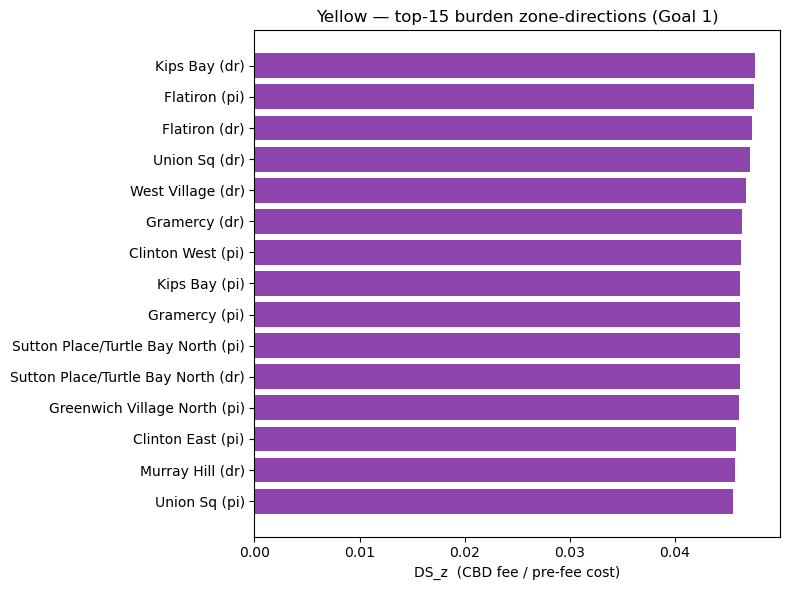

Overall top 15:
                    zone_name direction   DS_z  DS_z_median    N_z
                     Kips Bay   dropoff 0.0476       0.0466 174406
                     Flatiron    pickup 0.0475       0.0466 235158
                     Flatiron   dropoff 0.0473       0.0475 219240
                     Union Sq   dropoff 0.0471       0.0466 372281
                 West Village   dropoff 0.0467       0.0466 263614
                     Gramercy   dropoff 0.0464       0.0466 284967
                 Clinton West    pickup 0.0463       0.0455  75181
                     Kips Bay    pickup 0.0462       0.0455 142690
                     Gramercy    pickup 0.0462       0.0457 285732
Sutton Place/Turtle Bay North    pickup 0.0462       0.0455 254119
Sutton Place/Turtle Bay North   dropoff 0.0462       0.0457 310457
      Greenwich Village North    pickup 0.0461       0.0457 213588
                 Clinton East    pickup 0.0458       0.0457 369419
                  Murray Hill   dropoff 0.0457

In [2]:
rank_cols = ['zone','direction','zone_name','Borough','DS_z','DS_z_median','N_z','DS_z_rank']

rank = m1.sort_values('DS_z', ascending=False).head(15)
rank[rank_cols].to_csv(TAB/'yellow_top_dsz_zone_directions.csv', index=False)

rank_pickup = m1[m1.direction.eq('pickup')].sort_values('DS_z', ascending=False).head(15)
rank_dropoff = m1[m1.direction.eq('dropoff')].sort_values('DS_z', ascending=False).head(15)
rank_pickup[rank_cols].to_csv(TAB/'yellow_top_dsz_zone_directions_pickup.csv', index=False)
rank_dropoff[rank_cols].to_csv(TAB/'yellow_top_dsz_zone_directions_dropoff.csv', index=False)

labels = [f'{r.zone_name} ({r.direction[:2]})' for r in rank.itertuples()]
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(labels[::-1], rank['DS_z'].values[::-1], color='#8e44ad')
ax.set_xlabel('DS_z  (CBD fee / pre-fee cost)'); ax.set_title('Yellow — top-15 burden zone-directions (Goal 1)')
plt.tight_layout(); fig.savefig(FIG/'yellow_top_dsz_zone_directions.png', dpi=150, bbox_inches='tight'); plt.show()

print('Overall top 15:')
print(rank[['zone_name','direction','DS_z','DS_z_median','N_z']].round(4).to_string(index=False))
print('\nPickup-only top 15:')
print(rank_pickup[['zone_name','direction','DS_z','DS_z_median','N_z']].round(4).to_string(index=False))
print('\nDropoff-only top 15:')
print(rank_dropoff[['zone_name','direction','DS_z','DS_z_median','N_z']].round(4).to_string(index=False))


**Finding.** The highest-burden Yellow zone-directions are concentrated in the Manhattan core. The top overall list is led by Kips Bay, Flatiron, Union Sq, West Village, Gramercy, Clinton West, and Sutton Place/Turtle Bay North, with `DS_z` around 4.6-4.8%. Pickup-only and dropoff-only rankings are very similar, so the burden ranking is not mainly a pickup/dropoff artifact.


## 2. Burden map — `DS_z` choropleth

Zone-level `DS_z` is mapped using the NYC TLC taxi-zone geometry from the `taxi_zones` shapefile (`data/geo/taxi_zones/`). The shapefile uses the New York State Plane coordinate system. The first map averages pickup and dropoff `DS_z` within each zone as an overview; the next two maps show pickup-only and dropoff-only values. Saved to `results/burden_analysis/figures/yellow_dsz_choropleth.png`, `results/burden_analysis/figures/yellow_dsz_choropleth_pickup.png`, and `results/burden_analysis/figures/yellow_dsz_choropleth_dropoff.png`.


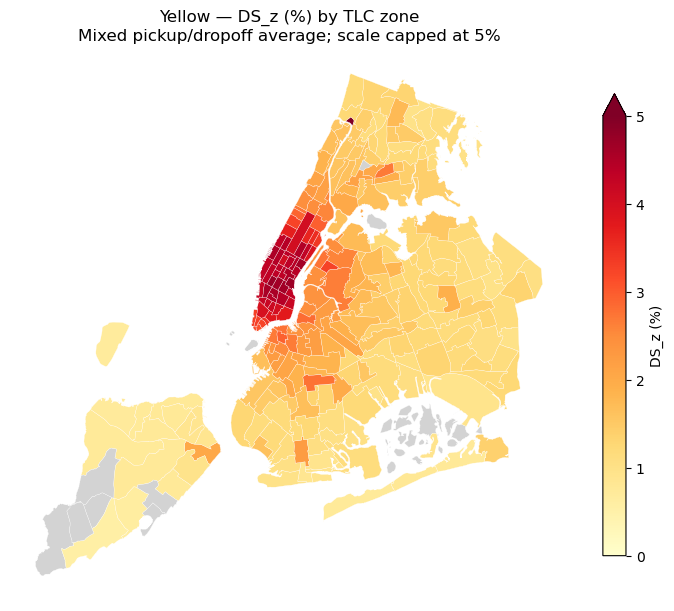

mixed: 253 zones with DS_z; range 0.006-0.101; saved yellow_dsz_choropleth.png


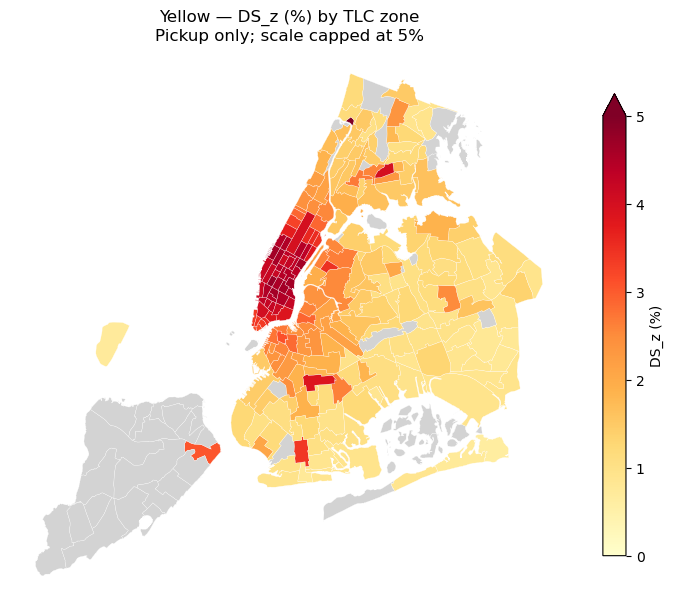

pickup: 224 zones with DS_z; range 0.006-0.188; saved yellow_dsz_choropleth_pickup.png


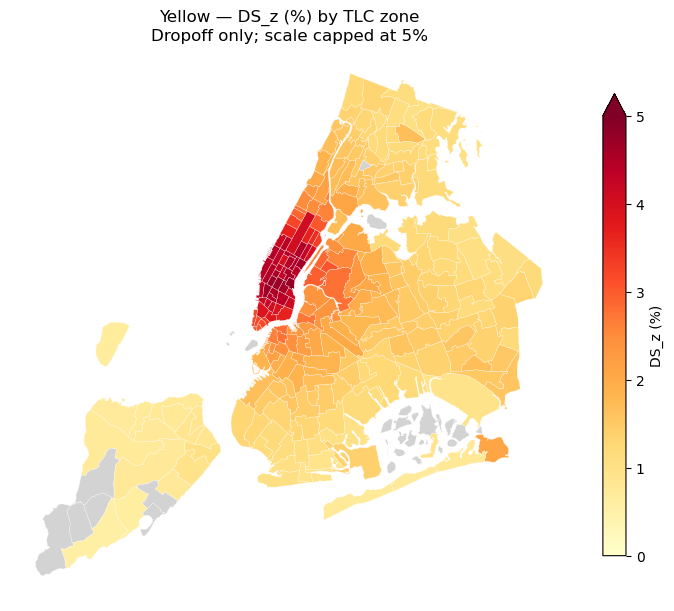

dropoff: 253 zones with DS_z; range 0.006-0.048; saved yellow_dsz_choropleth_dropoff.png


In [3]:
import shapefile
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

sf = shapefile.Reader(str(REPO/'data'/'geo'/'taxi_zones'/'taxi_zones.shp'))

def zone_values(direction=None):
    base = dv[~dv.low_n_flag].copy()
    if direction is None:
        return base.groupby('zone').DS_z.mean(), 'Mixed pickup/dropoff average', FIG/'yellow_dsz_choropleth.png'
    return (
        base[base.direction.eq(direction)].set_index('zone').DS_z,
        f'{direction.capitalize()} only',
        FIG/f'yellow_dsz_choropleth_{direction}.png',
    )

def draw_zone_map(values, title, out_path, cap_pct=5.0):
    patches, vals = [], []
    for rec, shp in zip(sf.records(), sf.shapes()):
        v = values.get(rec['LocationID'], np.nan)
        parts = list(shp.parts) + [len(shp.points)]
        for i in range(len(parts)-1):
            patches.append(Polygon(shp.points[parts[i]:parts[i+1]], closed=True))
            vals.append(v)
    vals = np.array(vals, float) * 100
    cmap = plt.cm.YlOrRd.copy(); cmap.set_bad('lightgrey')
    fig, ax = plt.subplots(figsize=(9, 10))
    pc = PatchCollection(patches, cmap=cmap, edgecolor='white', linewidth=0.2)
    pc.set_array(np.ma.masked_invalid(vals))
    pc.set_clim(0, cap_pct)
    ax.add_collection(pc); ax.autoscale_view(); ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'Yellow — DS_z (%) by TLC zone\n{title}; scale capped at {cap_pct:.0f}%')
    cb = fig.colorbar(pc, ax=ax, shrink=0.6, extend='max'); cb.set_label('DS_z (%)')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    return vals

for direction in [None, 'pickup', 'dropoff']:
    vals, title, out_path = zone_values(direction)
    rendered = draw_zone_map(vals, title, out_path)
    label = 'mixed' if direction is None else direction
    print(f'{label}: {vals.notna().sum()} zones with DS_z; range {vals.min():.3f}-{vals.max():.3f}; saved {out_path.name}')


**Finding.** The choropleth maps show that Yellow `DS_z` is spatially concentrated in the Manhattan core. The pickup-only and dropoff-only maps show broadly similar geography, which supports using the mixed map as an overview while keeping pickup/dropoff-specific rankings in the tables.

## 3. Ranking stability — base-cost floor check

Rank stability and top-zone overlap are compared against the primary $1-floor definition from the DS_z pipeline outputs. This check confirms the audit expectation: for Yellow, the base-cost floor does not materially drive the ranking, because very few charged card/cash trips have near-zero base cost.


In [4]:
rankstab = pd.read_csv(DS/'yellow_ds_rank_stability.csv')
overlap  = pd.read_csv(DS/'yellow_ds_top_zone_overlap.csv')
print('Rank stability vs the $1 primary (mean, all directions):')
print(rankstab[(rankstab.aggregation_method=='mean') & (rankstab.direction=='all')]
      [['denominator_floor','spearman_rank_corr_vs_primary','mean_abs_rank_delta','max_abs_rank_delta']].round(3).to_string(index=False))
print('\nTop-10/20 zone overlap vs $1 primary (mean, share):')
print(overlap[overlap.aggregation_method=='mean'].groupby(['denominator_floor','top_n']).overlap_share.mean().round(3).to_string())
rankstab_export = (rankstab[(rankstab.aggregation_method == 'mean') & (rankstab.direction == 'all')]
                   [['denominator_floor','spearman_rank_corr_vs_primary','mean_abs_rank_delta','max_abs_rank_delta']]
                   .sort_values('denominator_floor'))
overlap_export = (overlap[overlap.aggregation_method == 'mean']
                  .groupby(['denominator_floor','top_n'], as_index=False).overlap_share.mean()
                  .sort_values(['denominator_floor','top_n']))
rankstab_export.to_csv(TAB/'yellow_dsz_floor_rank_stability.csv', index=False)
overlap_export.to_csv(TAB/'yellow_dsz_floor_top_overlap.csv', index=False)


Rank stability vs the $1 primary (mean, all directions):
 denominator_floor  spearman_rank_corr_vs_primary  mean_abs_rank_delta  max_abs_rank_delta
               0.5                          1.000                0.000                   0
               1.0                          1.000                0.000                   0
               2.0                          0.998                0.574                  89
               5.0                          0.996                1.823                  89

Top-10/20 zone overlap vs $1 primary (mean, share):
denominator_floor  top_n
0.5                10       1.0
                   20       1.0
1.0                10       1.0
                   20       1.0
2.0                10       1.0
                   20       1.0
5.0                10       1.0
                   20       1.0


## 4. Heterogeneity — geography of burden

This section summarizes where Yellow `DS_z` is highest across broad geographic strata. Output is a burden distribution table. Saved to `results/burden_analysis/tables/yellow_burden_by_borough.csv` and `results/burden_analysis/tables/yellow_burden_by_borough_direction.csv`. EWR is kept separate because Newark is not a NYC airport-fee zone.


In [5]:
burden_rows = []
for zt in ['manhattan', 'outer', 'airport', 'ewr']:
    sub = m1[m1.zone_type.eq(zt)].copy()
    if sub.empty:
        continue
    top = sub.sort_values('DS_z', ascending=False).iloc[0]
    burden_rows.append({
        'stratum': zt,
        'n_zone_dir': len(sub),
        'mean_DS_z': sub.DS_z.mean(),
        'median_DS_z': sub.DS_z.median(),
        'p25_DS_z': sub.DS_z.quantile(0.25),
        'p75_DS_z': sub.DS_z.quantile(0.75),
        'max_DS_z': sub.DS_z.max(),
        'top_zone': top.zone_name if pd.notna(top.zone_name) else f'zone {int(top.zone)}',
        'top_direction': top.direction,
    })

burden_geo = pd.DataFrame(burden_rows)
burden_geo.to_csv(TAB/'yellow_burden_by_borough.csv', index=False)
print('Yellow DS_z by geographic stratum:')
print(burden_geo.round(4).to_string(index=False))

direction_geo = (m1.groupby(['zone_type', 'direction'], observed=True)
                 .agg(n_zone_dir=('DS_z', 'size'), median_DS_z=('DS_z', 'median'), mean_DS_z=('DS_z', 'mean'))
                 .reset_index())
direction_geo.to_csv(TAB/'yellow_burden_by_borough_direction.csv', index=False)
print('\nYellow DS_z by stratum and direction:')
print(direction_geo.round(4).to_string(index=False))


Yellow DS_z by geographic stratum:
  stratum  n_zone_dir  mean_DS_z  median_DS_z  p25_DS_z  p75_DS_z  max_DS_z          top_zone top_direction
manhattan         126     0.0370       0.0408    0.0318    0.0444    0.0476          Kips Bay       dropoff
    outer         197     0.0167       0.0150    0.0123    0.0203    0.0421          zone 264       dropoff
  airport           4     0.0108       0.0108    0.0094    0.0122    0.0123 LaGuardia Airport       dropoff
      ewr           1     0.0067       0.0067    0.0067    0.0067    0.0067    Newark Airport       dropoff

Yellow DS_z by stratum and direction:
zone_type direction  n_zone_dir  median_DS_z  mean_DS_z
  airport   dropoff           2       0.0109     0.0109
  airport    pickup           2       0.0106     0.0106
      ewr   dropoff           1       0.0067     0.0067
manhattan   dropoff          66       0.0400     0.0360
manhattan    pickup          60       0.0416     0.0381
    outer   dropoff         154       0.0146     0

**Finding.** Yellow burden is much higher in Manhattan than elsewhere. The median `DS_z` is about 4.1% for Manhattan zone-directions, compared with about 1.5% for outer-borough zone-directions and about 1.1% for JFK/LaGuardia airport zone-directions. The stable EWR entry has the lowest measured burden in this table.


## 5. Heterogeneity — trip-length disaggregation

This section recomputes `DS_z` by zone×direction×length bucket, then summarizes the pattern within Manhattan. Yellow's own charged-trip distance thresholds (p25 = 1.07 mi, p75 = 3.11 mi) define short / medium / long. Saved to `results/burden_analysis/tables/yellow_burden_by_trip_length.csv`.


In [6]:
P25, P75 = 1.07, 3.11
con = duckdb.connect(); con.execute('SET threads TO 1')
con.execute(f"""
CREATE OR REPLACE TABLE ds_by_len AS
WITH t AS (
  SELECT PULocationID, DOLocationID,
    CASE WHEN trip_distance_miles < {P25} THEN 'short'
         WHEN trip_distance_miles <= {P75} THEN 'medium' ELSE 'long' END AS trip_length,
    cbd_congestion_fee / GREATEST(ROUND(passenger_cost_pretip - cbd_congestion_fee, 2), 1.00) AS fee_burden
  FROM read_parquet('{YELLOW_GLOB}')
  WHERE year=2025 AND charged_cbd_flag AND yellow_card_or_cash_flag AND cbd_congestion_fee>0
    AND ROUND(passenger_cost_pretip - cbd_congestion_fee, 2) > 0
    AND NOT (zero_distance_flag AND (PULocationID=DOLocationID OR trip_duration_seconds<60))
),
pu AS (SELECT PULocationID AS zone,'pickup' AS direction,trip_length,MEDIAN(fee_burden) AS DS_z_med,COUNT(*) AS n FROM t GROUP BY PULocationID,trip_length),
do_ AS (SELECT DOLocationID AS zone,'dropoff' AS direction,trip_length,MEDIAN(fee_burden) AS DS_z_med,COUNT(*) AS n FROM t GROUP BY DOLocationID,trip_length)
SELECT * FROM pu UNION ALL SELECT * FROM do_
""")
bylen = con.execute('SELECT * FROM ds_by_len').df()
ml = bylen.merge(dv[['zone','direction','Borough','low_n_flag']], on=['zone','direction'])
ml = ml[(ml.Borough=='Manhattan') & (~ml.low_n_flag) & (ml.n>=30)]
out = []
for lg in ['short','medium','long']:
    s = ml[ml.trip_length==lg].copy(); s['q'] = pd.qcut(s.DS_z_med, 4, labels=[1,2,3,4])
    g = s.groupby('q', observed=True).agg(
    mean_DS_z=('DS_z_med','mean'), median_DS_z=('DS_z_med','median'),
    n_zone_directions=('DS_z_med','size'), median_trip_count=('n','median'),
).reset_index()
    g.insert(0,'trip_length',lg); out.append(g)
res = pd.concat(out, ignore_index=True); res.to_csv(TAB/'yellow_burden_by_trip_length.csv', index=False)
print('Within-Manhattan, DS_z quartiles by trip length:'); print(res.round(4).to_string(index=False))
print('\nBurden by length (Q1 vs Q4):')
for lg in ['short','medium','long']:
    s = res[res.trip_length==lg]
    print(f'  {lg:7s}: DS_z Q1={s[s.q==1].mean_DS_z.iloc[0]:.1%} -> Q4={s[s.q==4].mean_DS_z.iloc[0]:.1%}')

Within-Manhattan, DS_z quartiles by trip length:
trip_length q  mean_DS_z  median_DS_z  n_zone_directions  median_trip_count
      short 1     0.0515       0.0547                 33             1423.0
      short 2     0.0595       0.0595                 22            38298.5
      short 3     0.0613       0.0615                 35            35443.0
      short 4     0.0632       0.0630                 19            53140.0
     medium 1     0.0379       0.0391                 33            34411.0
     medium 2     0.0409       0.0412                 42            87311.0
     medium 3     0.0420       0.0421                 19           103868.0
     medium 4     0.0435       0.0436                 19           116206.0
       long 1     0.0172       0.0171                 33            19406.0
       long 2     0.0231       0.0231                 33            33057.0
       long 3     0.0245       0.0244                 38            35686.5
       long 4     0.0261       0.0261  

**Finding.** Within Manhattan, shorter trips carry higher measured burden because the $0.75 fee is fixed while the pre-fee trip cost is lower. Short-trip `DS_z` is roughly 5-6%, medium-trip burden is around 4%, and long-trip burden is around 2%. This supports the main burden interpretation: the fee weighs more heavily on shorter, lower-cost Yellow trips.


## 6. Heterogeneity — airport vs non-airport burden

We use the trip-level `airport_trip_flag` (JFK/LaGuardia) to compare airport and non-airport trips. Saved to `results/burden_analysis/tables/yellow_airport_vs_nonairport_burden.csv`.


In [7]:
ap = con.execute(f"""
SELECT airport_trip_flag,
  COUNT(*) AS n,
  ROUND(MEDIAN(passenger_cost_pretip),2) AS med_cost,
  ROUND(MEDIAN(trip_distance_miles),2) AS med_dist,
  ROUND(AVG(charged_cbd_flag::INT),4) AS charged_share,
  ROUND(MEDIAN(CASE WHEN charged_cbd_flag THEN cbd_congestion_fee/GREATEST(ROUND(passenger_cost_pretip-cbd_congestion_fee,2),1.00) END),4) AS med_burden_charged
FROM read_parquet('{YELLOW_GLOB}')
WHERE year=2025 AND yellow_card_or_cash_flag
  AND NOT (zero_distance_flag AND (PULocationID=DOLocationID OR trip_duration_seconds<60))
GROUP BY airport_trip_flag ORDER BY airport_trip_flag
""").df()
ap['group'] = np.where(ap.airport_trip_flag, 'airport', 'non-airport')
ap = ap[['group','n','med_cost','med_dist','charged_share','med_burden_charged']]
ap.to_csv(TAB/'yellow_airport_vs_nonairport_burden.csv', index=False)
print('Yellow airport vs non-airport (2025 card/cash):'); print(ap.to_string(index=False))

Yellow airport vs non-airport (2025 card/cash):
      group        n  med_cost  med_dist  charged_share  med_burden_charged
non-airport 13561290     17.85      1.58         0.7784              0.0419
    airport  1193343     67.85     11.80         0.4752              0.0099


**Finding.** Airport trips have lower measured burden than non-airport trips. They are longer and much higher-cost, so the flat $0.75 fee is a small share of pre-fee cost when charged. They are also charged less often because JFK and LaGuardia are outside the CRZ, so many airport trips do not touch the charging zone.


## 7. Summary

**Burden ranking.** The highest-burden Yellow zone-sides are concentrated in the dense Manhattan core (Kips Bay, Flatiron, Union Sq, West Village, Gramercy...), with `DS_z` around 4.6-4.8%. The ranking is stable across the base-cost floor checks: Spearman rank correlation versus the $1 primary is at least 0.996 across $0.50-$5, and top-10/20 overlap is 100% at every floor.

**Burden is larger on shorter, lower-cost trips; airport trips have lower measured burden.** Within Manhattan, `DS_z` is roughly 6% for short trips, 4% for medium trips, and 2% for long trips. Airport trips (JFK/LaGuardia, about 8% of card/cash trips) have much higher median cost ($67.85), are charged less often (47.5% vs 77.8%), and when charged have lower median burden (0.99% vs 4.19% for non-airport trips). The choropleth shows the same spatial pattern: burden is highest in the Manhattan core and lower farther out.

**Geography matters for burden.** The burden ranking is concentrated in Manhattan, especially dense core zones. Outer-borough and airport/EWR zone-directions have lower measured `DS_z` because trips are usually longer or higher-cost, so the flat $0.75 fee is a smaller share of the pre-fee cost.

**Net:** the Goal-1 burden ranking is stable and interpretable, and Yellow burden clearly varies by trip length and airport status.
